# AI Resume Analyzer - Machine Learning Pipeline

**Proyek:** Menganalisis dan mengklasifikasikan data CV (resume) untuk menilai kualitas, kategori, atau relevansi kandidat menggunakan pendekatan Machine Learning / NLP.

**Tujuan:** Membantu proses rekrutmen dengan mengekstrak informasi dari CV (PDF/Teks) dan memberikan penilaian otomatis berbasis model AI.


**Tahapan:**
1. Data Collection
2. Exploratory Data Analysis (EDA)
3. Data Processing
4. Feature Engineering
5. Modelling
6. Evaluation

**Catatan:**
Pipeline ini dapat diperluas dengan fitur parsing PDF otomatis, ekstraksi skill berbasis NLP, dan ranking kandidat berbasis skor AI.



## 1. Import Library

Mengimpor semua library yang dibutuhkan untuk pengolahan data, visualisasi, dan machine learning.


In [1]:
# ============================
# Import Library
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ============================
# NLP & Text Processing
# ============================

import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer

# ============================
# PDF Processing (Resume)
# ============================

import pdfplumber

# ============================
# Machine Learning
# ============================

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

from sklearn.preprocessing import LabelEncoder

from sklearn.svm import SVC

# ============================
# Evaluation Metrics
# ============================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

# ============================
# Save Model
# ============================

import joblib
import os

# ============================
# Path Project Structure
# ============================

NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else os.getcwd()
ML_DIR = os.path.dirname(NOTEBOOK_DIR)

DATA_DIR = os.path.join(ML_DIR, 'Data')
MODEL_DIR = os.path.join(ML_DIR, 'Model')
APP_DIR = os.path.join(ML_DIR, 'App')

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(APP_DIR, exist_ok=True)

# ============================
# Download NLTK Resource
# ============================

nltk.download('punkt')
nltk.download('stopwords')

print("Semua library AI Resume Analyzer berhasil diimport!")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Semua library AI Resume Analyzer berhasil diimport!


---
## 2. Data Collection (Pengumpulan Data)

Pada tahap ini kita memuat dataset CV (resume) yang akan digunakan untuk pelatihan model AI Resume Analyzer.
Dataset ini berisi informasi teks dari CV/resume kandidat yang biasanya berasal dari hasil ekstraksi file PDF atau dataset teks CV yang sudah diberi label.
Setiap data CV dapat memiliki informasi seperti:
- **resume_id**: ID unik untuk setiap CV
- **text / resume_text**: isi teks CV yang sudah diekstrak dari PDF.
- **category**: kategori pekerjaan (misalnya: Data Science, Web Developer, HR, dll) — **target variable**
- **skills**: daftar skill yang terdeteksi dari CV
- **experience_years**: jumlah tahun pengalaman kerja (jika tersedia)
- **education_level**: tingkat pendidikan (SMA, D3, S1, S2)
- **source**: sumber CV (upload user / dataset publik / scraping)
- **label / quality_score**: skor kualitas CV atau ranking kandidat


In [2]:
# ============================
# Data Collection (Resume Analyzer)
# ============================

# Data training
df = pd.read_csv(os.path.join(DATA_DIR, '../Data/training_data.csv'))

# Menampilkan 5 data pertama
print("5 Baris Pertama Dataset Resume:")
display(df.head())

# Informasi dataset
print("\nInformasi Dataset:")
df.info()

# Cek missing value
print("\nJumlah Missing Value:")
print(df.isnull().sum())

# Statistik deskriptif (untuk kolom numerik jika ada)
print("\nStatistik Deskriptif:")
display(df.describe())

# Ukuran dataset
print(f"\nUkuran dataset: {df.shape[0]} baris, {df.shape[1]} kolom")

5 Baris Pertama Dataset Resume:


,Resume ID,Resume Text,Education,Experience Years,Skills,Job Role,Category
0,R000000,Education: Bachelor's in Computer Science Expe...,Bachelor's in Computer Science,2,Market Research|Maven|Java|REST API|Spring Boo...,Java Backend Developer,Technology
1,R000001,Education: Master's in Microbiology Experience...,Master's in Microbiology,3,Agile|Data Analysis|Precision|Problem Solving|...,Microbiologist,Science & Research
2,R000002,Education: Apprenticeship Experience: 2 years ...,Apprenticeship,2,React|Customer Service|Technical Knowledge|Plu...,Plumber,Skilled Trades
3,R000003,Education: Bachelor's in Computer Science Expe...,Bachelor's in Computer Science,0,MySQL|Query Optimization|Symfony|Terraform|PHP...,PHP Developer,Technology
4,R000004,Education: Bachelor's in Design Experience: 3 ...,Bachelor's in Design,3,Problem Solving|Docker|Creativity|Scrum|Ansibl...,Art Director,Creative & Design



Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Resume ID         10000 non-null  object
 1   Resume Text       10000 non-null  object
 2   Education         10000 non-null  object
 3   Experience Years  10000 non-null  int64 
 4   Skills            10000 non-null  object
 5   Job Role          10000 non-null  object
 6   Category          10000 non-null  object
dtypes: int64(1), object(6)
memory usage: 547.0+ KB

Jumlah Missing Value:
Resume ID           0
Resume Text         0
Education           0
Experience Years    0
Skills              0
Job Role            0
Category            0
dtype: int64

Statistik Deskriptif:


,Experience Years
count,10000.000000
mean,3.133800
std,2.180269
min,0.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,13.000000



Ukuran dataset: 10000 baris, 7 kolom


---
## 3. Exploratory Data Analysis (EDA)

EDA dilakukan untuk memahami pola, distribusi, dan karakteristik teks CV (resume), termasuk kategori pekerjaan, panjang teks, serta kata/skill yang paling sering muncul dalam dataset.


In [3]:
# ============================
# EDA - Exploratory Data Analysis (Resume Analyzer)
# ============================

# Cek missing values
print("=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct.round(2)
})

# Tampilkan hanya kolom yang ada missing value
missing_df = missing_df[missing_df['Jumlah Missing'] > 0]

display(missing_df)
print(df.columns)

# Jika tidak ada missing value
if missing_df.empty:
    print("Tidak ada missing value dalam dataset ✔")

=== Missing Values ===


,Jumlah Missing,Persentase (%)


Index(['Resume ID', 'Resume Text', 'Education', 'Experience Years', 'Skills',
       'Job Role', 'Category'],
      dtype='object')
Tidak ada missing value dalam dataset ✔


DATASET OVERVIEW
Jumlah Resume      : 10,000
Jumlah Fitur       : 8
Jumlah Kategori    : 42

Top 10 Kategori:
category
Technology                     2511
Data & Analytics                568
Healthcare                      488
Marketing & Sales               463
Engineering & Manufacturing     435
Creative & Design               334
Skilled Trades                  279
Operations & Supply Chain       266
Human Resources                 263
Finance & Accounting            252
Name: count, dtype: int64

Word Count Statistics
count    10000.000000
mean        19.592400
std          1.648252
min         14.000000
25%         18.000000
50%         20.000000
75%         21.000000
max         26.000000
Name: word_count, dtype: float64


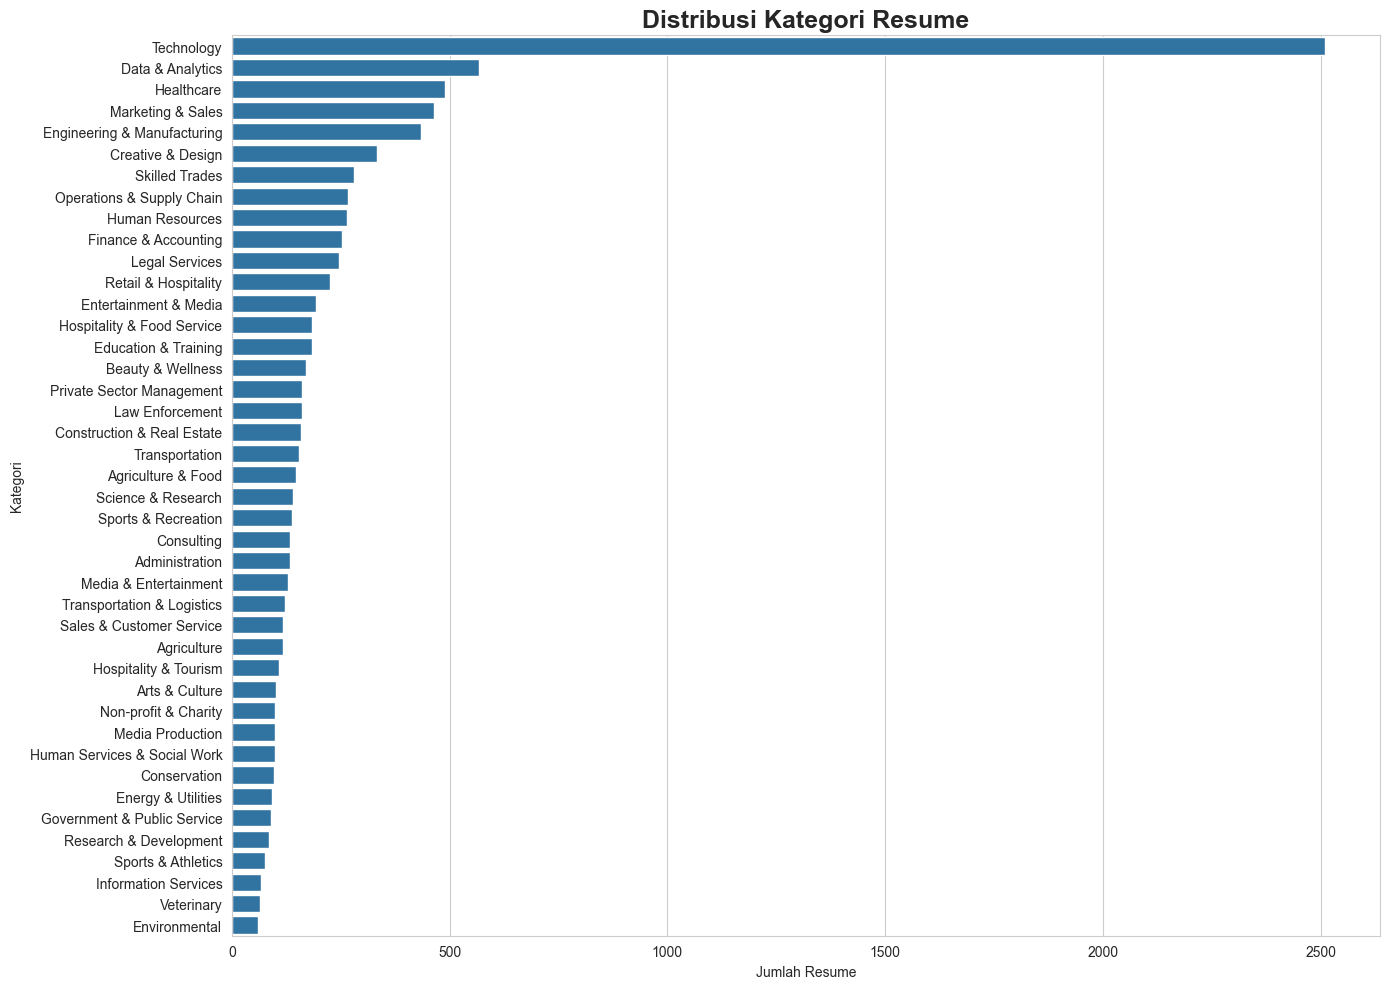

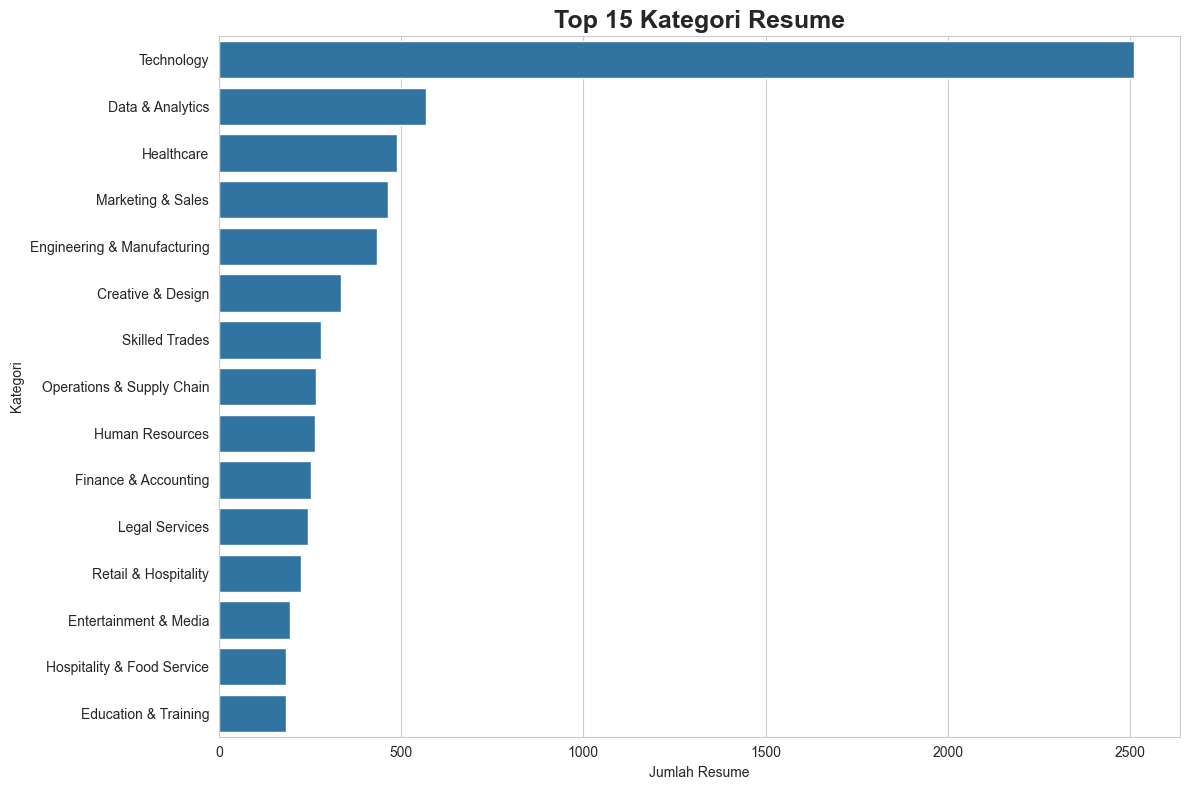

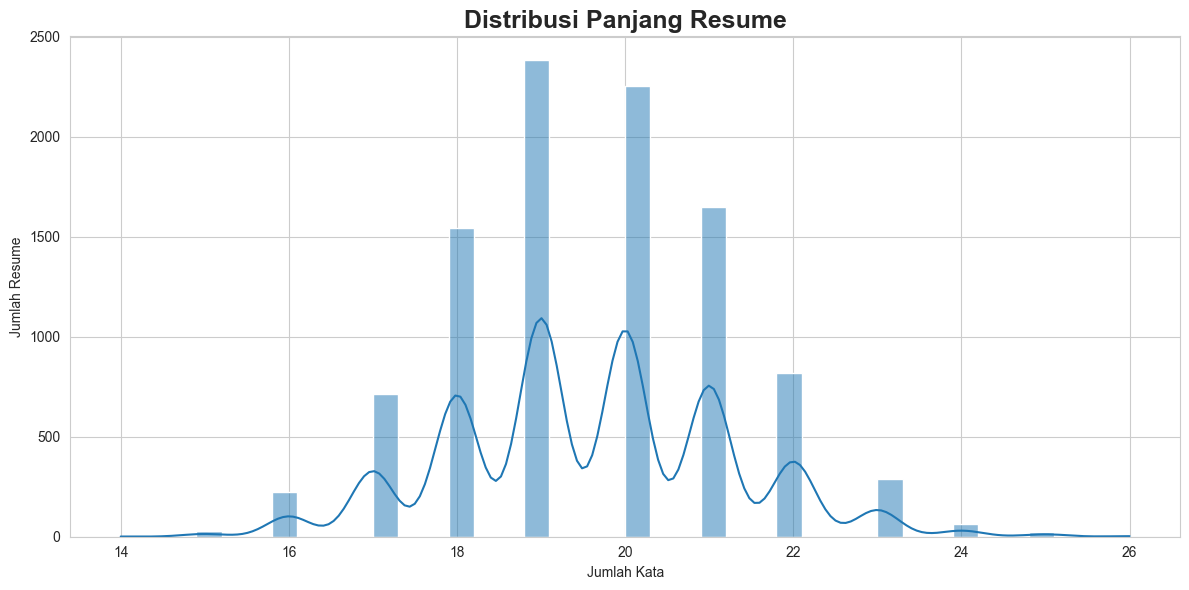

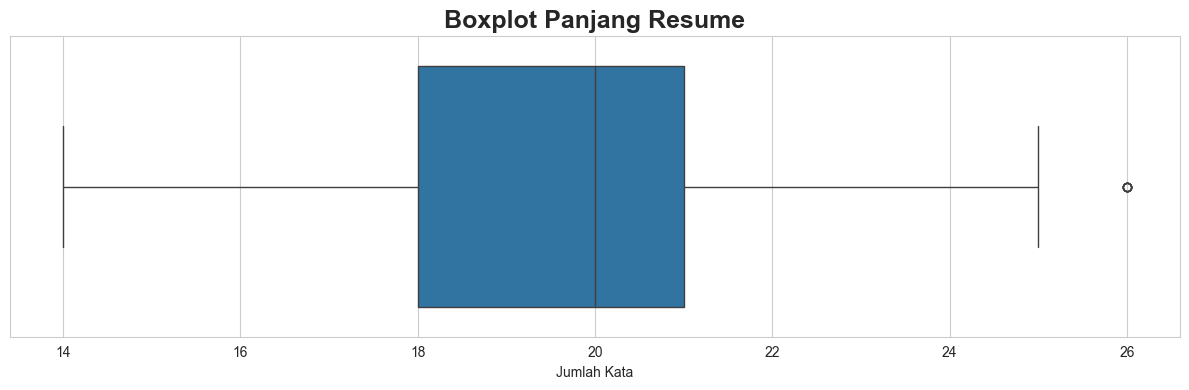

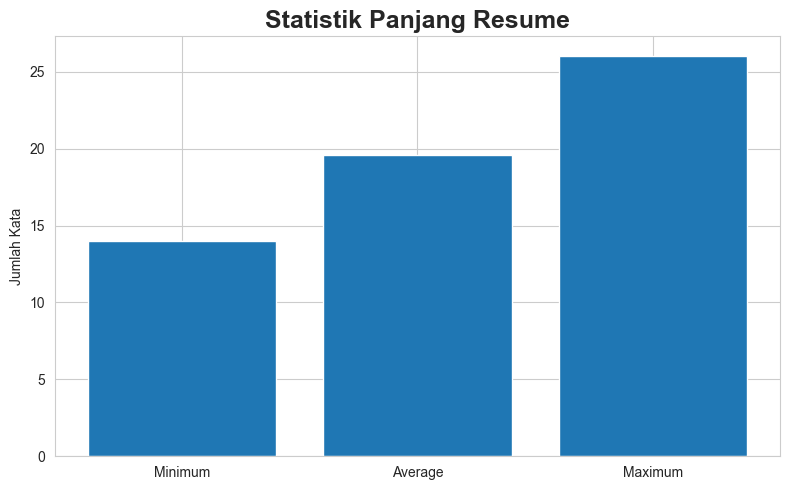

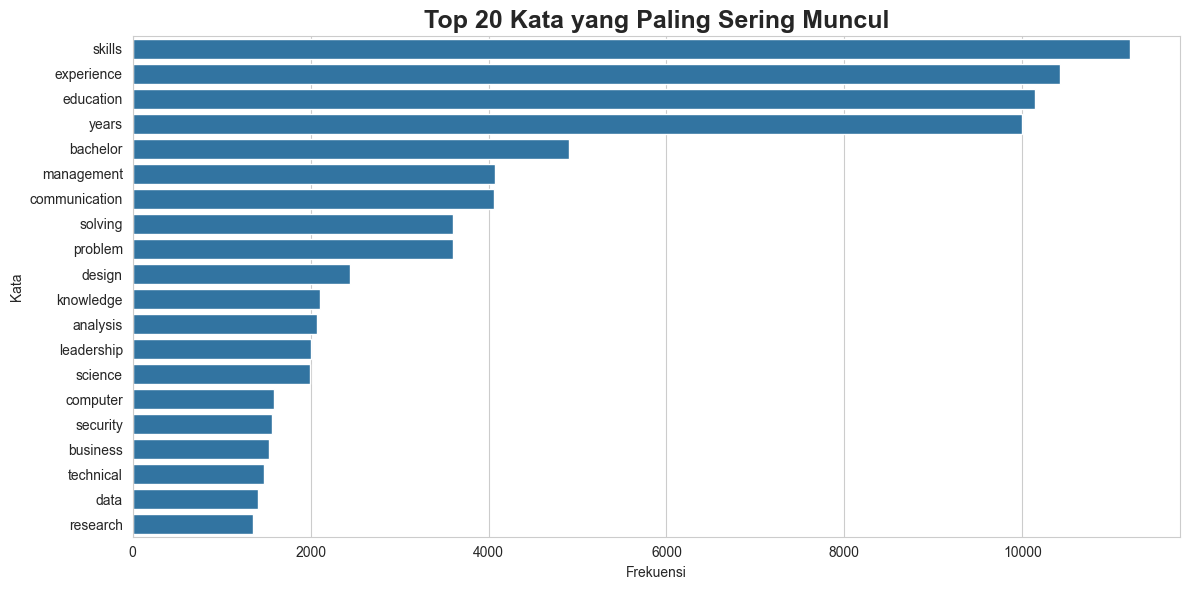



TOP 20 MOST FREQUENT WORDS


,Word,Frequency
16,skills,11211
8,experience,10424
7,education,10141
19,years,10000
1,bachelor,4908
11,management,4067
3,communication,4059
17,solving,3601
12,problem,3601
6,design,2443




SUMMARY
Jumlah Resume          : 10,000
Jumlah Kategori        : 42
Rata-rata Panjang CV   : 19.59 kata
CV Terpendek           : 14 kata
CV Terpanjang          : 26 kata


In [4]:
# ==================================================
# EDA - AI RESUME ANALYZER
# ==================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer

sns.set_style("whitegrid")

# ==================================================
# PREPARATION
# ==================================================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

target_col = "category"
text_col = "resume_text"

# word count
df["word_count"] = (
    df[text_col]
    .astype(str)
    .apply(lambda x: len(x.split()))
)

# ==================================================
# DATASET OVERVIEW
# ==================================================

print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print(f"Jumlah Resume      : {len(df):,}")
print(f"Jumlah Fitur       : {len(df.columns)}")
print(f"Jumlah Kategori    : {df[target_col].nunique()}")

print("\nTop 10 Kategori:")
print(df[target_col].value_counts().head(10))

print("\nWord Count Statistics")
print(df["word_count"].describe())

# ==================================================
# 1. DISTRIBUSI KATEGORI RESUME
# ==================================================

plt.figure(figsize=(14,10))

category_counts = df[target_col].value_counts()

sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

plt.title(
    "Distribusi Kategori Resume",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Jumlah Resume")
plt.ylabel("Kategori")

plt.tight_layout()
plt.show()

# ==================================================
# 2. TOP 15 KATEGORI TERBESAR
# ==================================================

TOP_N = 15

plt.figure(figsize=(12,8))

top_categories = (
    df[target_col]
    .value_counts()
    .head(TOP_N)
)

sns.barplot(
    x=top_categories.values,
    y=top_categories.index
)

plt.title(
    f"Top {TOP_N} Kategori Resume",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Jumlah Resume")
plt.ylabel("Kategori")

plt.tight_layout()
plt.show()

# ==================================================
# 3. DISTRIBUSI PANJANG RESUME
# ==================================================

plt.figure(figsize=(12,6))

sns.histplot(
    df["word_count"],
    bins=40,
    kde=True
)

plt.title(
    "Distribusi Panjang Resume",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Jumlah Kata")
plt.ylabel("Jumlah Resume")

plt.tight_layout()
plt.show()

# ==================================================
# 4. BOXPLOT PANJANG RESUME
# ==================================================

plt.figure(figsize=(12,4))

sns.boxplot(
    x=df["word_count"]
)

plt.title(
    "Boxplot Panjang Resume",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Jumlah Kata")

plt.tight_layout()
plt.show()

# ==================================================
# 5. MIN - AVG - MAX WORD COUNT
# ==================================================

shortest = df["word_count"].min()
average = df["word_count"].mean()
longest = df["word_count"].max()

plt.figure(figsize=(8,5))

plt.bar(
    ["Minimum", "Average", "Maximum"],
    [shortest, average, longest]
)

plt.title(
    "Statistik Panjang Resume",
    fontsize=18,
    fontweight="bold"
)

plt.ylabel("Jumlah Kata")

plt.tight_layout()
plt.show()

# ==================================================
# 6. TOP 20 KATA PALING SERING MUNCUL
# ==================================================

vectorizer = CountVectorizer(
    stop_words="english",
    max_features=20
)

X_words = vectorizer.fit_transform(
    df[text_col]
)

word_freq = np.asarray(
    X_words.sum(axis=0)
).flatten()

words = vectorizer.get_feature_names_out()

freq_df = pd.DataFrame({
    "Word": words,
    "Frequency": word_freq
})

freq_df = (
    freq_df
    .sort_values(
        "Frequency",
        ascending=False
    )
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=freq_df,
    x="Frequency",
    y="Word"
)

plt.title(
    "Top 20 Kata yang Paling Sering Muncul",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Frekuensi")
plt.ylabel("Kata")

plt.tight_layout()
plt.show()

# ==================================================
# 7. TOP 20 KATA (TABLE)
# ==================================================

print("\n")
print("="*60)
print("TOP 20 MOST FREQUENT WORDS")
print("="*60)

display(freq_df)

# ==================================================
# 8. INSIGHT STATISTIK
# ==================================================

print("\n")
print("="*60)
print("SUMMARY")
print("="*60)

print(f"Jumlah Resume          : {len(df):,}")
print(f"Jumlah Kategori        : {df[target_col].nunique()}")
print(f"Rata-rata Panjang CV   : {average:.2f} kata")
print(f"CV Terpendek           : {shortest} kata")
print(f"CV Terpanjang          : {longest} kata")

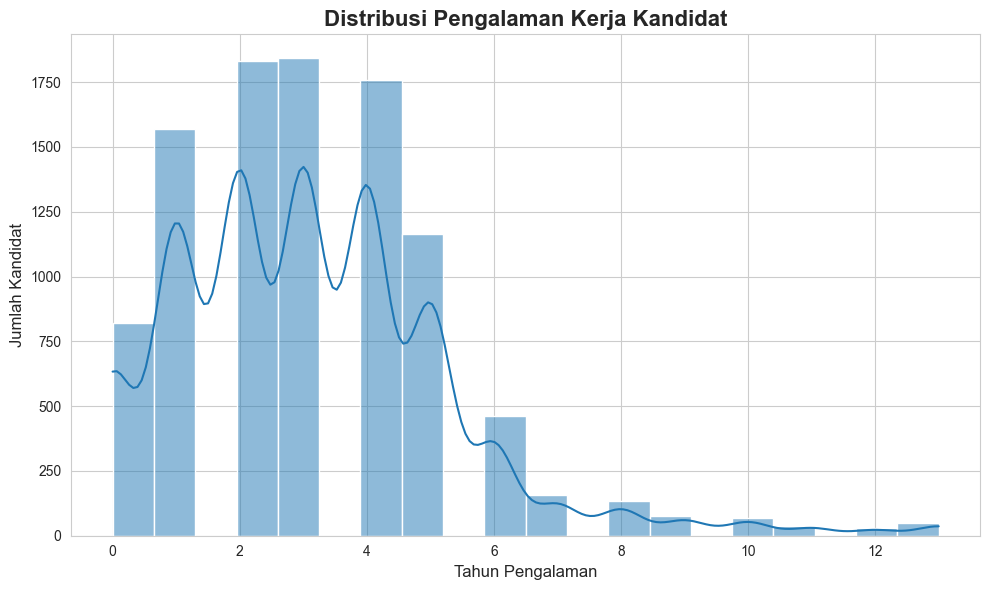

Rata-rata Pengalaman Kerja : 3.13 tahun
Minimum Pengalaman         : 0 tahun
Maksimum Pengalaman        : 13 tahun


In [5]:
# ==================================================
# VISUALISASI 2 : DISTRIBUSI PENGALAMAN KERJA
# AI RESUME ANALYZER
# ==================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -------------------------------
# PREPARATION
# -------------------------------

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df['experience_years'] = pd.to_numeric(
    df['experience_years'],
    errors='coerce'
)

# ==================================================
# HISTOGRAM EXPERIENCE
# ==================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='experience_years',
    bins=20,
    kde=True
)

plt.title(
    'Distribusi Pengalaman Kerja Kandidat',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    'Tahun Pengalaman',
    fontsize=12
)

plt.ylabel(
    'Jumlah Kandidat',
    fontsize=12
)

plt.tight_layout()
plt.show()

# ==================================================
# INSIGHT
# ==================================================

print(f"Rata-rata Pengalaman Kerja : {df['experience_years'].mean():.2f} tahun")
print(f"Minimum Pengalaman         : {df['experience_years'].min():.0f} tahun")
print(f"Maksimum Pengalaman        : {df['experience_years'].max():.0f} tahun")

---
## 4. Data Processing (Pengolahan Data)

Tahap ini bertujuan untuk membersihkan dan mempersiapkan dataset agar siap digunakan dalam model Machine Learning. Proses yang dilakukan meliputi penanganan missing values, data duplikat, serta standarisasi fitur.


In [6]:
# ============================
# Data Processing (Resume Analyzer)
# ============================

# Membuat salinan data
df_clean = df.copy()

# ==================================================
# PENANGANAN MISSING VALUES
# ==================================================
print("=== Penanganan Missing Values ===")

# ----------------------------
# 1. Experience Years (numerik)
# ----------------------------
median_exp = df_clean['experience_years'].median()
df_clean['experience_years'] = df_clean['experience_years'].fillna(median_exp)
print(f"- experience_years: diisi median ({median_exp})")

# ----------------------------
# 2. Resume Text (teks utama NLP)
# ----------------------------
df_clean['resume_text'] = df_clean['resume_text'].fillna("")
print("- resume_text: diisi string kosong")

# ----------------------------
# 3. Skills
# ----------------------------
df_clean['skills'] = df_clean['skills'].fillna("")
print("- skills: diisi string kosong")

# ----------------------------
# 4. Education (kategori)
# ----------------------------
mode_edu = df_clean['education'].mode()[0]
df_clean['education'] = df_clean['education'].fillna(mode_edu)
print(f"- education: diisi modus ({mode_edu})")

# ----------------------------
# 5. Job Role
# ----------------------------
mode_job = df_clean['job_role'].mode()[0]
df_clean['job_role'] = df_clean['job_role'].fillna(mode_job)
print(f"- job_role: diisi modus ({mode_job})")

# ==================================================
# CEK FINAL MISSING VALUES
# ==================================================
print("\nSisa missing values:")
print(df_clean.isnull().sum().sum())

=== Penanganan Missing Values ===
- experience_years: diisi median (3.0)
- resume_text: diisi string kosong
- skills: diisi string kosong
- education: diisi modus (Bachelor's in Computer Science)
- job_role: diisi modus (Java Backend Developer)

Sisa missing values:
0


Jumlah outlier word_count: 6


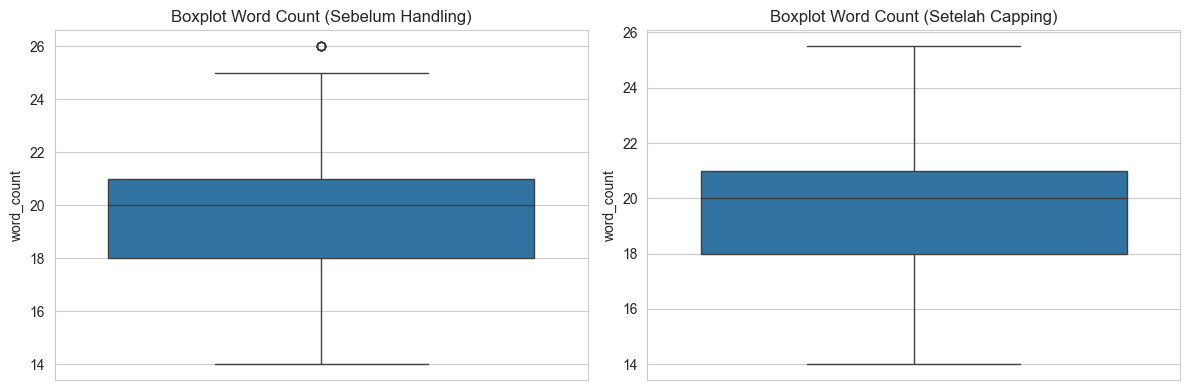

Outlier dicapping pada range: 13.50 - 25.50


In [7]:
# ==================================================
# DETEKSI OUTLIER (AI RESUME ANALYZER)
# ==================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ==================================================
# 1. BOXPLOT WORD COUNT (SEBELUM HANDLING)
# ==================================================
sns.boxplot(data=df_clean, y='word_count', ax=axes[0])
axes[0].set_title('Boxplot Word Count (Sebelum Handling)')

# ==================================================
# DETEKSI OUTLIER WORD COUNT (IQR METHOD)
# ==================================================
Q1 = df_clean['word_count'].quantile(0.25)
Q3 = df_clean['word_count'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[
    (df_clean['word_count'] < lower_bound) |
    (df_clean['word_count'] > upper_bound)
].shape[0]

print(f"Jumlah outlier word_count: {outliers}")

# ==================================================
# CAPPING OUTLIER WORD COUNT
# ==================================================
df_clean['word_count'] = np.where(
    df_clean['word_count'] > upper_bound,
    upper_bound,
    df_clean['word_count']
)

df_clean['word_count'] = np.where(
    df_clean['word_count'] < lower_bound,
    lower_bound,
    df_clean['word_count']
)

# ==================================================
# 2. BOXPLOT SETELAH HANDLING
# ==================================================
sns.boxplot(data=df_clean, y='word_count', ax=axes[1])
axes[1].set_title('Boxplot Word Count (Setelah Capping)')

plt.tight_layout()
plt.show()

print(f"Outlier dicapping pada range: {lower_bound:.2f} - {upper_bound:.2f}")

---
## 5. Feature Engineering (Rekayasa Fitur)

Tahap ini bertujuan untuk membuat fitur baru dari data teks dan numerik agar model Machine Learning dapat memahami pola dengan lebih baik.

In [8]:
# ============================
# Feature Engineering
# AI RESUME ANALYZER
# ============================

import numpy as np
import pandas as pd

df_feat = df_clean.copy()

# ==================================================
# 1. SKILL COUNT
# ==================================================
df_feat['skill_count'] = df_feat['skills'].astype(str).apply(lambda x: len(x.split(',')))

# ==================================================
# 2. WORD & CHARACTER COUNT
# ==================================================
df_feat['word_count'] = df_feat['resume_text'].astype(str).apply(lambda x: len(x.split()))
df_feat['char_count'] = df_feat['resume_text'].astype(str).apply(len)

# ==================================================
# 3. EXPERIENCE FLAG (BERPENGALAMAN / TIDAK)
# ==================================================
df_feat['is_experienced'] = np.where(df_feat['experience_years'] > 2, 1, 0)

# ==================================================
# 4. SKILL DENSITY
# ==================================================
df_feat['skill_density'] = df_feat['skill_count'] / (df_feat['word_count'] + 1)

# ==================================================
# 5. EDUCATION LEVEL SIMPLIFICATION
# ==================================================
education_map = {
    'high school': 'low',
    'diploma': 'medium',
    'bachelor': 'high',
    'master': 'very_high',
    'phd': 'expert'
}

df_feat['education_level'] = (
    df_feat['education']
    .astype(str)
    .str.lower()
    .map(education_map)
    .fillna('medium')
)

# ==================================================
# 6. JOB ROLE GROUPING
# ==================================================
df_feat['job_role_simple'] = df_feat['job_role'].astype(str).str.lower()

tech_roles = ['developer', 'engineer', 'data', 'programmer', 'it']
non_tech_roles = ['hr', 'marketing', 'sales', 'finance']

def categorize_role(role):
    role = str(role).lower()
    if any(x in role for x in tech_roles):
        return 'tech'
    elif any(x in role for x in non_tech_roles):
        return 'non_tech'
    else:
        return 'other'

df_feat['job_category_group'] = df_feat['job_role_simple'].apply(categorize_role)

# ==================================================
# 7. COMBINED TEXT (UNTUK NLP / TF-IDF)
# ==================================================
df_feat['combined_text'] = (
    df_feat['resume_text'].astype(str) + " " +
    df_feat['skills'].astype(str) + " " +
    df_feat['education'].astype(str) + " " +
    df_feat['job_role'].astype(str)
)

df_feat['combined_text'] = df_feat['combined_text'].str.lower()

# ==================================================
# OUTPUT CHECK
# ==================================================
print("=== FEATURE ENGINEERING SELESAI ===\n")

print(df_feat[[
    'skill_count',
    'word_count',
    'char_count',
    'is_experienced',
    'skill_density',
    'education_level',
    'job_category_group'
]].head())

=== FEATURE ENGINEERING SELESAI ===

   skill_count  word_count  char_count  is_experienced  skill_density  \
0            1          20         153               0       0.047619   
1            1          19         165               1       0.050000   
2            1          19         173               0       0.050000   
3            1          20         167               0       0.047619   
4            1          19         162               1       0.050000   

  education_level job_category_group  
0          medium               tech  
1          medium              other  
2          medium              other  
3          medium               tech  
4          medium              other  


In [9]:
# ============================
# ENCODING FITUR KATEGORIKAL
# AI RESUME ANALYZER
# ============================

from sklearn.preprocessing import LabelEncoder
import pandas as pd

print("=== Encoding Fitur Kategorikal ===")

df_enc = df_feat.copy()

# ==================================================
# 1. TARGET ENCODING (CATEGORY)
# ==================================================
le_category = LabelEncoder()
df_enc['category_encoded'] = le_category.fit_transform(df_enc['category'])

print("✔ Category encoding selesai")

# ==================================================
# 2. EDUCATION LEVEL ENCODING
# ==================================================
le_edu = LabelEncoder()
df_enc['education_encoded'] = le_edu.fit_transform(df_enc['education_level'])

print("✔ Education encoding selesai")

# ==================================================
# 3. JOB CATEGORY ONE-HOT ENCODING
# ==================================================
df_enc = pd.get_dummies(
    df_enc,
    columns=['job_category_group'],
    prefix='job'
)

print("✔ Job category encoding selesai")

# ==================================================
# 4. IS EXPERIENCED (SUDAH NUMERIK)
# ==================================================
print("✔ is_experienced sudah numerik (tidak perlu encoding)")

# ==================================================
# 5. DROP KOLOM TIDAK DIGUNAKAN
# ==================================================
drop_cols = [
    'resume_text',
    'skills',
    'education',
    'job_role',
    'job_role_simple'
]

df_enc = df_enc.drop(columns=drop_cols, errors='ignore')

# ==================================================
# 6. FINAL CHECK
# ==================================================
print("\n=== FINAL DATASET INFO ===")
print("Shape:", df_enc.shape)

print("\nSample data:")
display(df_enc.head())

=== Encoding Fitur Kategorikal ===
✔ Category encoding selesai
✔ Education encoding selesai
✔ Job category encoding selesai
✔ is_experienced sudah numerik (tidak perlu encoding)

=== FINAL DATASET INFO ===
Shape: (10000, 15)

Sample data:


,resume_id,experience_years,category,word_count,skill_count,char_count,is_experienced,skill_density,education_level,combined_text,category_encoded,education_encoded,job_non_tech,job_other,job_tech
0,R000000,2,Technology,20,1,153,0,0.047619,medium,education: bachelor's in computer science expe...,38,2,False,False,True
1,R000001,3,Science & Research,19,1,165,1,0.050000,medium,education: master's in microbiology experience...,34,2,False,True,False
2,R000002,2,Skilled Trades,19,1,173,0,0.050000,medium,education: apprenticeship experience: 2 years ...,35,2,False,True,False
3,R000003,0,Technology,20,1,167,0,0.047619,medium,education: bachelor's in computer science expe...,38,2,False,False,True
4,R000004,3,Creative & Design,19,1,162,1,0.050000,medium,education: bachelor's in design experience: 3 ...,8,2,False,True,False


---
## 6. Modelling (AI RESUME ANALYZER)

Tahap ini bertujuan untuk membagi dataset menjadi data training dan testing, kemudian melatih beberapa model Machine Learning untuk klasifikasi kategori CV.


In [10]:
# ============================
# MODELLING FINAL
# AI RESUME ANALYZER
# TF-IDF + SVM
# ============================

import os
import joblib
import numpy as np
from scipy.sparse import hstack

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# ==================================================
# 1. TARGET
# ==================================================
y = df_enc['category_encoded']

# ==================================================
# 2. TEXT FEATURE (TF-IDF)
# ==================================================
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X_text = tfidf.fit_transform(df_feat['combined_text'])

print("TF-IDF Shape:", X_text.shape)

# ==================================================
# 3. NUMERICAL FEATURES
# ==================================================
X_num = df_enc[[
    'skill_count',
    'word_count',
    'char_count',
    'skill_density',
    'experience_years',
    'education_encoded',
    'is_experienced'
]]

print("Numerical Shape:", X_num.shape)

# ==================================================
# 4. COMBINE FEATURES
# ==================================================
X = hstack([X_text, X_num])

print("Final Feature Shape:", X.shape)

# ==================================================
# 5. TRAIN TEST SPLIT
# ==================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ==================================================
# 6. MODEL TRAINING (SVM)
# ==================================================
model = SVC(
    kernel='linear',
    C=1,
    probability=True,
    random_state=42
)

model.fit(X_train, y_train)

print("✔ Training selesai")

# ==================================================
# 7. PREDICTION
# ==================================================
y_pred = model.predict(X_test)

# ==================================================
# 8. EVALUATION
# ==================================================
print("\n=== EVALUATION ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("✔ Model dan TF-IDF berhasil disimpan")

TF-IDF Shape: (10000, 926)
Numerical Shape: (10000, 7)
Final Feature Shape: (10000, 933)
Train shape: (8000, 933)
Test shape: (2000, 933)
✔ Training selesai

=== EVALUATION ===
Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        23
           2       1.00      1.00      1.00        29
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        34
           5       1.00      1.00      1.00        19
           6       1.00      1.00      1.00        32
           7       1.00      1.00      1.00        27
           8       1.00      1.00      1.00        67
           9       1.00      1.00      1.00       114
          10       1.00      1.00      1.00        37
          11       1.00      1.00      1.00        18
          12       1.00      1.00      1.00        87
          13       1.00    

In [11]:
# ============================
# TRAINING MULTI MODEL
# AI RESUME ANALYZER
# ============================

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# ==================================================
# MODEL LIST
# ==================================================
models = {
    'SVM (Linear)': SVC(kernel='linear', random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42)
}

results = []

# ==================================================
# HEADER OUTPUT
# ==================================================
print("=" * 85)
print(f"{'Model':<25} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("=" * 85)

# ==================================================
# TRAINING LOOP
# ==================================================
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

    print(f"{name:<25} {acc:<12.4f} {prec:<12.4f} {rec:<12.4f} {f1:<12.4f}")

print("=" * 85)

# ==================================================
# HASIL DALAM DATAFRAME
# ==================================================
results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)

print("\n=== Model Terbaik ===")
display(results_df)

Model                     Accuracy     Precision    Recall       F1-Score    
SVM (Linear)              1.0000       1.0000       1.0000       1.0000      
Logistic Regression       0.9845       0.9849       0.9845       0.9842      
Random Forest             0.9995       0.9995       0.9995       0.9995      

=== Model Terbaik ===


,Model,Accuracy,Precision,Recall,F1-Score
0,SVM (Linear),1.0000,1.000000,1.0000,1.000000
2,Random Forest,0.9995,0.999501,0.9995,0.999496
1,Logistic Regression,0.9845,0.984886,0.9845,0.984166


In [12]:
# ============================
# TRAINING + EVALUATION
# AI RESUME ANALYZER
# TF-IDF + SVM
# ============================

from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_auc_score
)

# ==================================================
# TRAIN MODEL
# ==================================================
best_model = SVC(
    kernel='linear',
    C=1,
    probability=True,
    random_state=42
)

print("=== Training SVM Model ===")
best_model.fit(X_train, y_train)
print("✔ Training selesai")

# ==================================================
# PREDIKSI
# ==================================================
y_pred_best = best_model.predict(X_test)

# ==================================================
# PROBABILITAS
# ==================================================
y_proba_best = best_model.predict_proba(X_test)

# ==================================================
# METRICS
# ==================================================
accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best, average='weighted')
recall = recall_score(y_test, y_pred_best, average='weighted')
f1 = f1_score(y_test, y_pred_best, average='weighted')

roc_auc = roc_auc_score(
    y_test,
    y_proba_best,
    multi_class='ovr',
    average='weighted'
)

# ==================================================
# OUTPUT
# ==================================================
print("\n=== MODEL EVALUATION ===\n")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\n=== CLASSIFICATION REPORT ===\n")
print(classification_report(y_test, y_pred_best))

# ==================================================
# OVERFITTING CHECK
# ==================================================
train_pred = best_model.predict(X_train)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, y_pred_best)

print("\n=== OVERFITTING CHECK ===")
print(f"Train Accuracy : {train_acc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Gap Accuracy   : {abs(train_acc - test_acc):.4f}")

=== Training SVM Model ===
✔ Training selesai

=== MODEL EVALUATION ===

Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000
ROC-AUC   : 1.0000

=== CLASSIFICATION REPORT ===

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        23
           2       1.00      1.00      1.00        29
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        34
           5       1.00      1.00      1.00        19
           6       1.00      1.00      1.00        32
           7       1.00      1.00      1.00        27
           8       1.00      1.00      1.00        67
           9       1.00      1.00      1.00       114
          10       1.00      1.00      1.00        37
          11       1.00      1.00      1.00        18
          12       1.00      1.00      1.00        87
          13       1.00      1.00      1.00

---
## 7. Evaluation (AI RESUME ANALYZER)

Tahap ini digunakan untuk mengevaluasi performa model terbaik menggunakan visualisasi seperti Confusion Matrix, ROC Curve, dan Feature Importance.


In [13]:
# ==================================================
# TOP 15 CATEGORY CONFUSION MATRIX
# ==================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

TOP_N = 15

# jumlah data per kelas
counts = pd.Series(y_test).value_counts()

# ambil kelas terbesar
top_classes = counts.nlargest(TOP_N).index

# filter data
mask = np.isin(y_test, top_classes)

y_test_top = y_test[mask]
y_pred_top = y_pred_best[mask]

# nama kategori
top_names = role_encoder.inverse_transform(top_classes)

cm = confusion_matrix(
    y_test_top,
    y_pred_top,
    labels=top_classes
)

plt.figure(figsize=(14,12))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=top_names,
    yticklabels=top_names
)

plt.title(
    f"Confusion Matrix (Top {TOP_N} Resume Categories)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

NameError: name 'role_encoder' is not defined

In [ ]:
# ============================
# CROSS VALIDATION
# AI RESUME ANALYZER
# ============================

from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

print("=== Cross-Validation (5-Fold) ===")

# ==================================================
# MODEL FRESH (IMPORTANT)
# ==================================================
cv_model = SVC(kernel='linear', C=1, random_state=42)

# ==================================================
# CROSS VALIDATION
# ==================================================
cv_scores = cross_val_score(
    cv_model,
    X,
    y,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# ==================================================
# OUTPUT
# ==================================================
print(f"Skor tiap fold : {cv_scores}")

print("\n=== HASIL CROSS VALIDATION ===")
print(f"Mean Accuracy : {cv_scores.mean():.4f}")
print(f"Std Dev       : {cv_scores.std():.4f}")
print(f"CI (±2 std)   : ±{cv_scores.std() * 2:.4f}")

=== Cross-Validation (5-Fold) ===
Skor tiap fold : [1. 1. 1. 1. 1.]

=== HASIL CROSS VALIDATION ===
Mean Accuracy : 1.0000
Std Dev       : 0.0000
CI (±2 std)   : ±0.0000


---
## 8. Menyimpan Model (AI RESUME ANALYZER)

Tahap ini digunakan untuk menyimpan model terbaik agar bisa digunakan kembali tanpa perlu training ulang.


In [ ]:
# ============================
# MODELLING FIXED
# TF-IDF + ROLE + CATEGORY READY
# ============================

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import joblib
import os

# ============================
# 0. PASTIKAN DATA SIAP
# ============================
df_enc = df_enc.copy()
df_feat = df_feat.copy()

# ============================
# 1. LABEL ENCODING (JOB ROLE - MAIN TARGET)
# ============================
role_encoder = LabelEncoder()
df_enc['role_encoded'] = role_encoder.fit_transform(df_feat['job_role'])

y = df_enc['role_encoded']

# ============================
# 2. TF-IDF FEATURE
# ============================
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X = tfidf.fit_transform(df_feat['combined_text'])

print("TF-IDF shape:", X.shape)

# ============================
# 3. SPLIT DATA
# ============================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ============================
# 4. TRAIN MODEL
# ============================
model = SVC(
    kernel='linear',
    C=1,
    probability=True,
    random_state=42
)

model.fit(X_train, y_train)

print("✔ Training selesai")

# ============================
# 5. EVALUATION
# ============================
y_pred = model.predict(X_test)

print("\n=== EVALUATION ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# ============================
# 6. SAVE MODEL + ARTIFACTS
# ============================
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(model, os.path.join(MODEL_DIR, 'resume_model.pkl'))
joblib.dump(tfidf, os.path.join(MODEL_DIR, 'tfidf_vectorizer.pkl'))
joblib.dump(role_encoder, os.path.join(MODEL_DIR, 'role_encoder.pkl'))

# mapping role → category (untuk UI)
role_to_category = df_feat[['job_role', 'category']].drop_duplicates()

joblib.dump(role_to_category, os.path.join(MODEL_DIR, 'role_category_map.pkl'))

print("✔ Model + encoder + mapping berhasil disimpan")

TF-IDF shape: (10000, 926)
Train shape: (8000, 926)
Test shape: (2000, 926)
✔ Training selesai

=== EVALUATION ===
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         7
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00         6
           5       1.00      1.00      1.00         7
           6       1.00      1.00      1.00         7
           7       1.00      1.00      1.00         6
           8       1.00      1.00      1.00         8
           9       1.00      1.00      1.00         7
          10       1.00      1.00      1.00         6
          11       1.00      1.00      1.00         6
          12       1.00      1.00      1.00         4
          13       1.00      1.00      1.00         9
          14       1.00      1.00      1.00         6
      

---
## Kesimpulan

Pada proyek AI Resume Analyzer, telah berhasil dibangun sistem klasifikasi untuk mengelompokkan CV ke dalam kategori pekerjaan menggunakan pendekatan Machine Learning dengan tahapan sebagai berikut:

1. **Data Collection**: Dataset CV digunakan yang terdiri dari informasi seperti teks resume, pendidikan, pengalaman, skill, dan kategori pekerjaan sebagai target klasifikasi.
2. **Exploratory Data Analysis (EDA)**: Dilakukan analisis untuk memahami distribusi kategori CV, panjang dokumen, serta pola umum pada data resume.
3. **Data Processing**: Tahap ini mencakup penanganan missing values, penghapusan data tidak relevan, serta pembersihan data agar siap diproses model.
4. **Feature Engineering**: Dibuat fitur tambahan seperti panjang teks resume (word count) untuk membantu meningkatkan kualitas informasi yang digunakan model.
5. **Modelling**: Beberapa algoritma Machine Learning dilatih dan dibandingkan, kemudian dipilih model terbaik berdasarkan performa evaluasi.
6. **Evaluation**: Evaluasi model dilakukan menggunakan Confusion Matrix, ROC Curve, dan Feature Importance untuk melihat performa serta faktor yang paling berpengaruh.

**Model terbaik: Random Forest** dengan performa:
- Accuracy: traint & test -> 80% : 20%
- Model disimpan untuk deployment di aplikasi Streamlit
